## Import libraies

In [257]:
import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error



## Read data

In [165]:
df=pd.read_csv(r"D:\Asmaa\ai_advanced_homework\home 3\ANN_Task.csv",skipinitialspace=True)

In [166]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [168]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [169]:
df.columns=df.columns.str.strip()

## Data visualization

In [170]:
VALUE_COL = "Life expectancy"        

url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"

m = folium.Map(location=[20, 0], zoom_start=2)

folium.Choropleth(
    geo_data=url,
    name="choropleth",
    data=df,
    columns=["Country","Life expectancy"],      
    key_on="feature.properties.name",    
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name=VALUE_COL
).add_to(m)

m


## fill null values

In [171]:
lst_null_value=df.columns[df.isnull().mean() * 100 > 0].tolist()


In [172]:
lst_null_value

['Life expectancy',
 'Adult Mortality',
 'Alcohol',
 'Hepatitis B',
 'BMI',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [173]:
df[lst_null_value]=df[lst_null_value].fillna(df[lst_null_value].median())

In [174]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

In [175]:
categorical_coloumns=df.select_dtypes(exclude=np.number)

In [176]:
categorical_coloumns

,Country,Status
0,Afghanistan,Developing
1,Afghanistan,Developing
2,Afghanistan,Developing
3,Afghanistan,Developing
4,Afghanistan,Developing
...,...,...
2933,Zimbabwe,Developing
2934,Zimbabwe,Developing
2935,Zimbabwe,Developing
2936,Zimbabwe,Developing


In [184]:
numerical_coloumns=df.select_dtypes(include=np.number).columns.tolist()

In [185]:
numerical_coloumns

['Year',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [187]:
corr=df[numerical_coloumns].corr()

<Axes: >

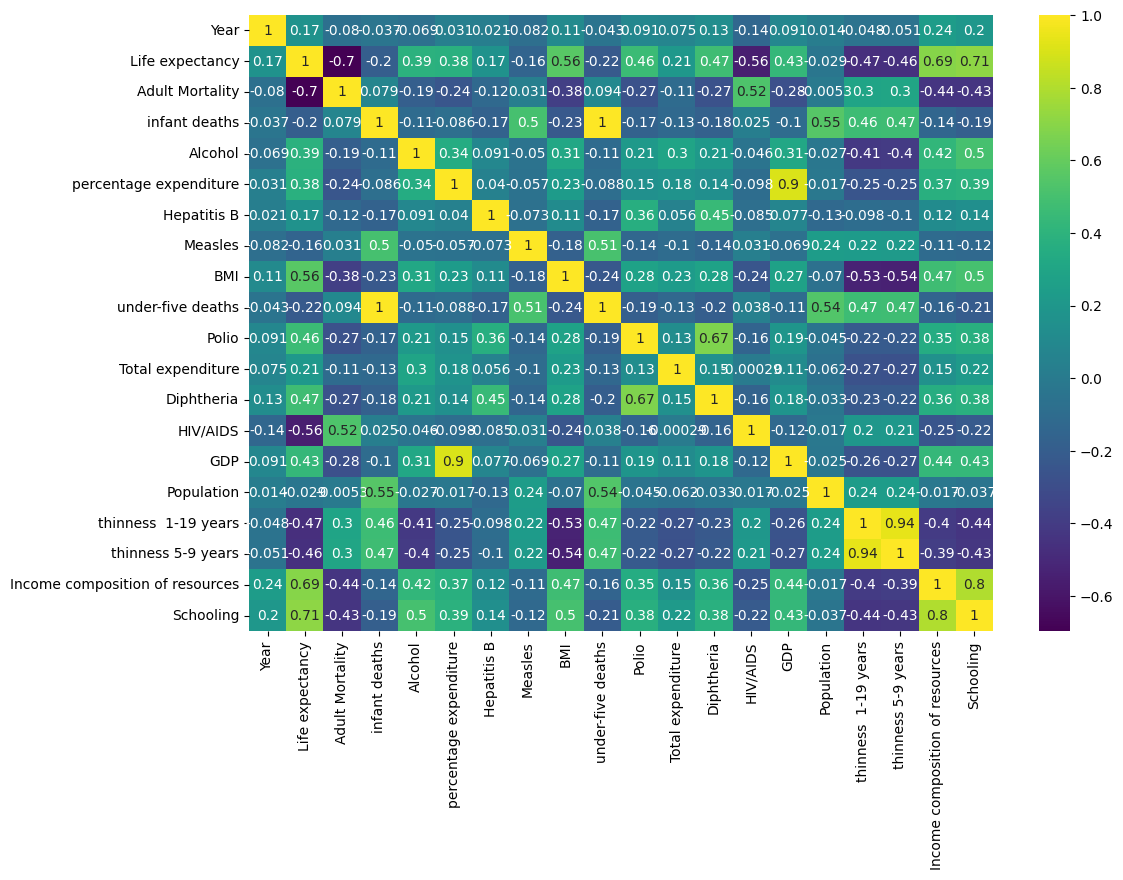

In [198]:
plt.figure(figsize=(12,8))

sns.heatmap(corr,annot=True,cmap='viridis')

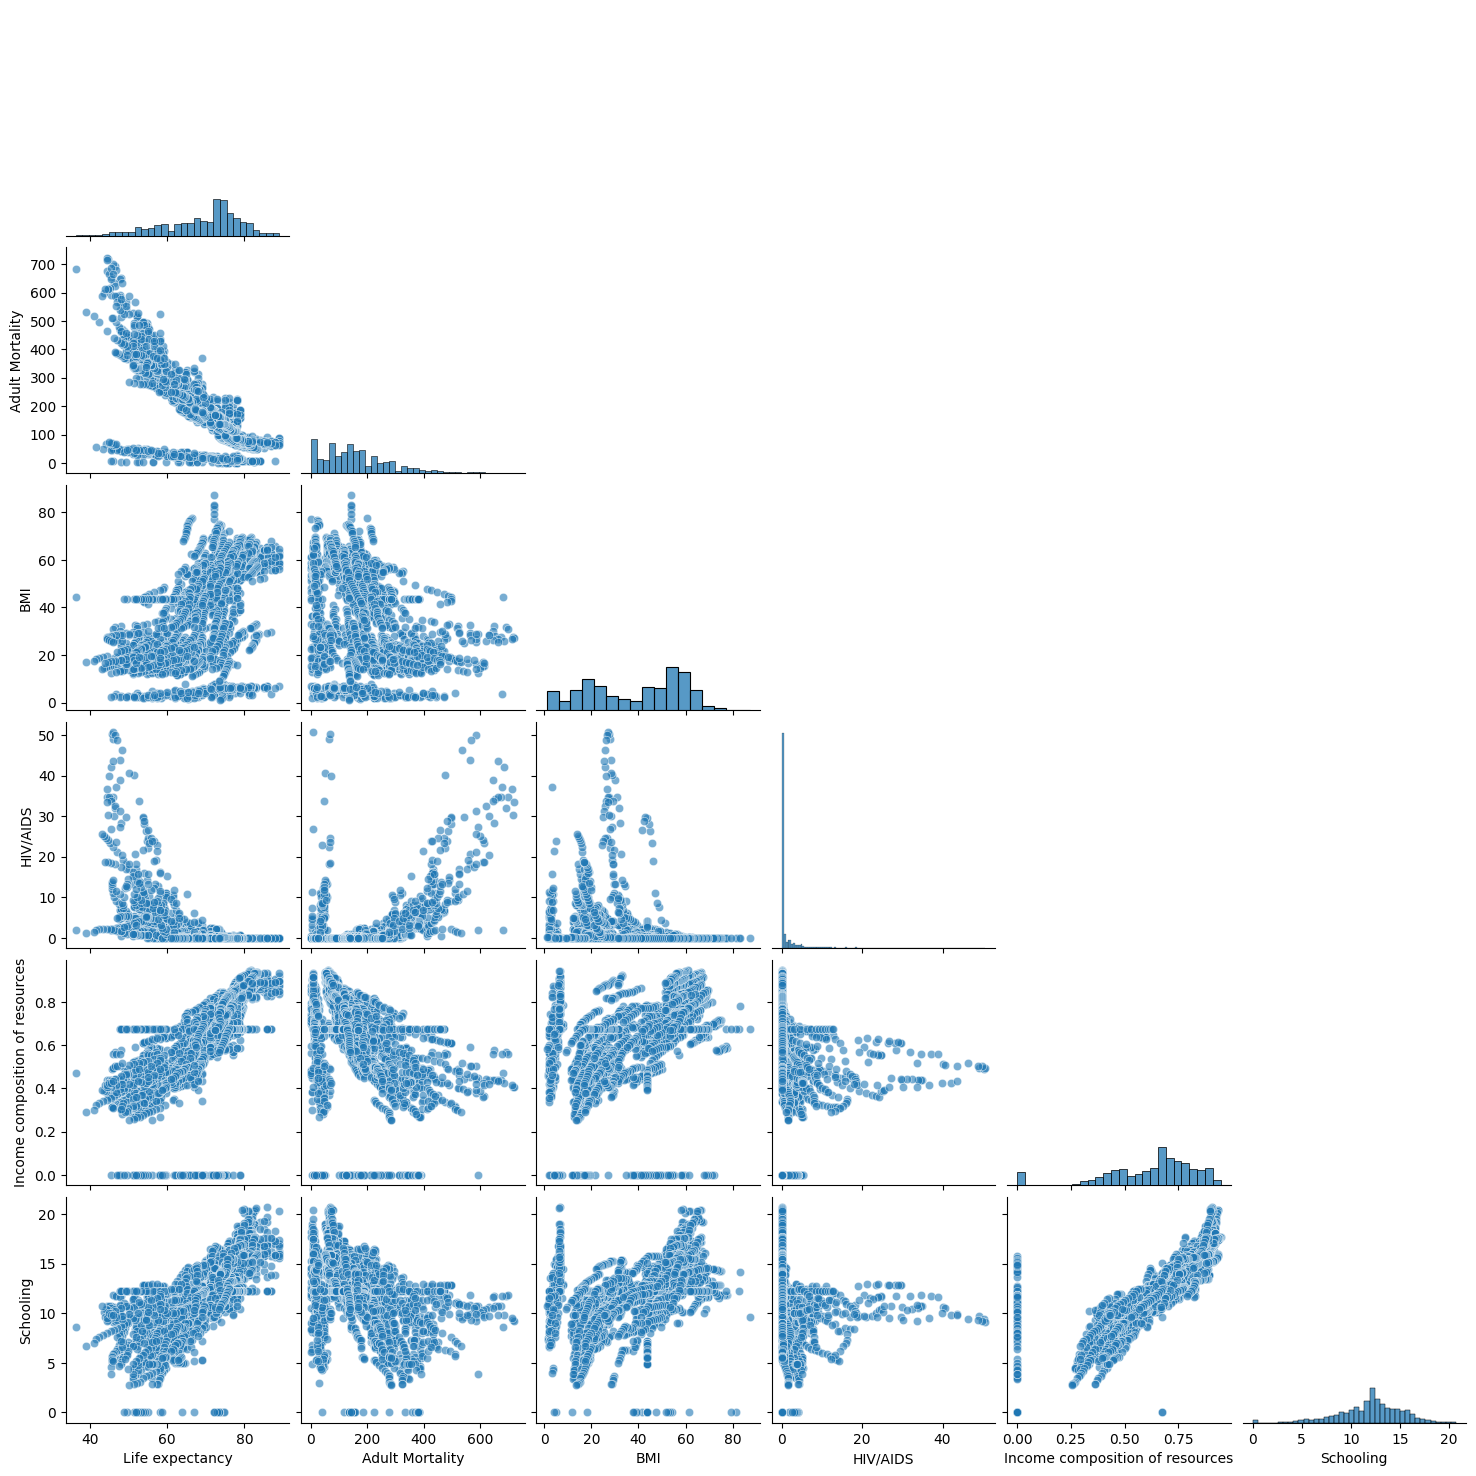

In [200]:
sns.pairplot(
    df[high_corr_with_target],
    corner=True,
    plot_kws={"alpha":0.6}
)
plt.show()


In [157]:
df.nunique()

Country                             193
Year                                 16
Status                                2
Life expectancy                     362
Adult Mortality                     425
infant deaths                       209
Alcohol                            1077
percentage expenditure             2328
Hepatitis B                          87
Measles                             958
BMI                                 608
under-five deaths                   252
Polio                                73
Total expenditure                   819
Diphtheria                           81
HIV/AIDS                            200
GDP                                2491
Population                         2279
thinness  1-19 years                200
thinness 5-9 years                  207
Income composition of resources     625
Schooling                           173
dtype: int64

## frequent encoding for country

In [158]:
freq_map = df['Country'].value_counts() / len(df)
df['Country_freq'] = df['Country'].map(freq_map)


In [159]:
df["Status"].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

## onehot encoding for status

In [160]:
df=pd.get_dummies(df,columns=['Status'],drop_first=True)

## label encoding for year

In [161]:
lb=LabelEncoder()


In [162]:
df['Year_le'] = lb.fit_transform(df['Year'])


In [163]:
x=df.drop(columns=["Country","Year","Life expectancy"])

In [164]:
y=df["Life expectancy"]

## Scaling

In [228]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [229]:

scaler_X = RobustScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [247]:

scaler_Y = RobustScaler()
Y_train_scaled = scaler_Y.fit_transform(y_train.values.reshape(-1,1))  
Y_test_scaled  = scaler_Y.transform(y_test.values.reshape(-1,1))


## Build Model

In [252]:
model = Sequential()
model.add(Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 16)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [253]:
history = model.fit(
    X_train_scaled,
    Y_train_scaled,
    batch_size=30,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 7.1468 - mae: 1.2109 - val_loss: 1.6696 - val_mae: 0.8512
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.3808 - mae: 0.7923 - val_loss: 0.9439 - val_mae: 0.6436
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2507 - mae: 0.6359 - val_loss: 0.6788 - val_mae: 0.5426
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8084 - mae: 0.5329 - val_loss: 0.5194 - val_mae: 0.4825
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5814 - mae: 0.4757 - val_loss: 0.4377 - val_mae: 0.4524
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4417 - mae: 0.4356 - val_loss: 0.3552 - val_mae: 0.4122
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3667 - mae: 0.4059 - val_loss: 0.3130 - val_mae: 0.3943
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3090 - mae: 0.3822 - val_loss: 0.2677 - val_mae: 0.3663
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2

In [254]:
y_pred_scaled = model.predict(X_test_scaled)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [255]:
y_pred_original = scaler_Y.inverse_transform(y_pred_scaled)
y_test_original = y_test.values.reshape(-1,1)

In [258]:
mae_original = mean_absolute_error(y_test_original, y_pred_original)
mse_original = mean_squared_error(y_test_original, y_pred_original)

print(f"MAE  = {mae_original:.2f}")
print(f"MSE  = {mse_original:.2f}")

MAE  = 2.29
MSE  = 12.14


## Plot Loss and MAE per epoch


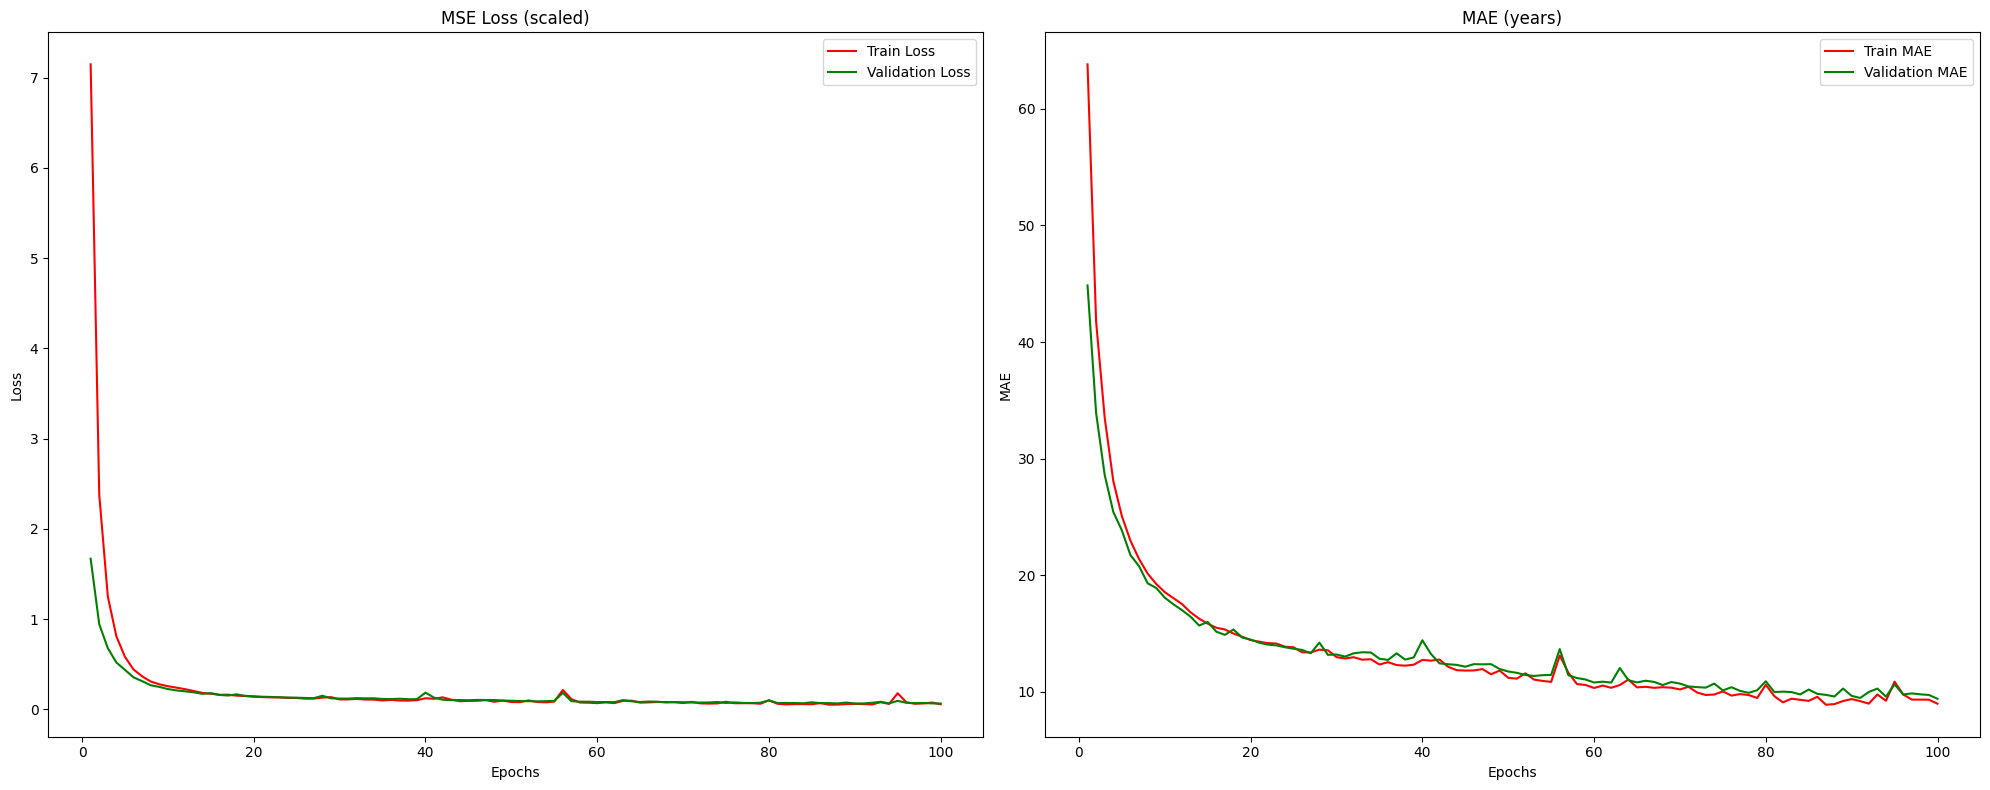

In [265]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mae_scaled = history.history['mae']
val_mae_scaled = history.history['val_mae']

# Approximate original MAE in years
train_mae_original = np.array(train_mae_scaled) * (y_train.max() - y_train.min())
val_mae_original = np.array(val_mae_scaled) * (y_train.max() - y_train.min())

epochs = [i+1 for i in range(len(train_loss))]

plt.figure(figsize=(20, 8))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'r', label='Train Loss')
plt.plot(epochs, val_loss, 'g', label='Validation Loss')
plt.title('MSE Loss (scaled)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(epochs, train_mae_original, 'r', label='Train MAE')
plt.plot(epochs, val_mae_original, 'g', label='Validation MAE')
plt.title('MAE (years)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()


## True vs Predicted Life Expectancy

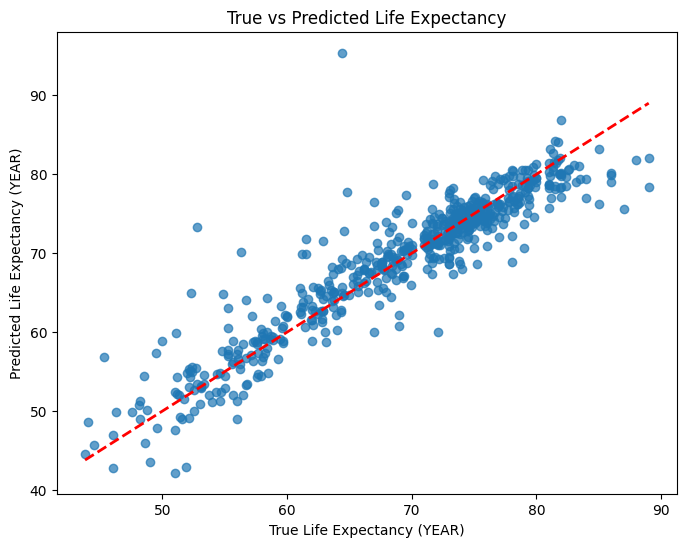

In [263]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', lw=2)
plt.xlabel("True Life Expectancy (YEAR)")
plt.ylabel("Predicted Life Expectancy (YEAR)")
plt.title("True vs Predicted Life Expectancy")
plt.show()